# Topic: Integrating Power BI and Python for Advanced customer Churn analysis and predictive modelling

Python modules used in this project

In [ ]:
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score

In [ ]:
os.environ['KAGGLE_CONFIG_DIR'] = '/content'

In [ ]:
!kaggle datasets download -d anandshaw2001/customer-churn-dataset
!unzip customer-churn-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/anandshaw2001/customer-churn-dataset
License(s): CC0-1.0
Archive:  customer-churn-dataset.zip
  inflating: Churn_Modelling.csv     


In [ ]:
churn_df = pd.read_csv('Churn_Modelling.csv')
churn_df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
print(churn_df.info())
print(churn_df.describe())
print(churn_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  1000

 drop irrelevant coulmns like customerID, rownumber, and surname
 and check for any non numeric values

In [ ]:
import json
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Preprocessing
def preprocess_data(df):
    # Drop irrelevant columns
    df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

    # Separate features and target
    X = df.drop('Exited', axis=1)
    y = df['Exited']

    # Define preprocessing
    numeric_features = ['CreditScore', 'Age', 'Tenure', 'Balance',
                      'NumOfProducts', 'EstimatedSalary']
    categorical_features = ['Geography', 'Gender']

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_features),
            ('cat', OneHotEncoder(drop='first'), categorical_features)
        ])

    X_processed = preprocessor.fit_transform(X)

    # Get feature names after one-hot encoding
    cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
    feature_names = numeric_features + list(cat_features)

    return X_processed, y, preprocessor, feature_names

# Apply preprocessing
X_processed, y, preprocessor, feature_names = preprocess_data(churn_df)

now defining feature and target for splitting the dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

Making a comparison between 5 different models
**SVM**, **Decision Tree** (Classification and regression tree), **Random Forest**, **adaboost**, **Logistic regression**

In [ ]:
models = {
    "SVM": SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_probe = model.predict_proba(X_test)[:, 1]  # Probability of positive class
    results[name] = {
        'Model': model,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_probe)
    }

# Convert results to DataFrame
results_df = pd.DataFrame(results).T
print(results_df)

/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


                                                                 Model  \
SVM                  SVC(class_weight='balanced', probability=True,...   
Logistic Regression  LogisticRegression(max_iter=1000, random_state...   
Decision Tree        DecisionTreeClassifier(max_depth=5, random_sta...   
Random Forest        (DecisionTreeClassifier(max_features='sqrt', r...   
AdaBoost             (DecisionTreeClassifier(max_depth=1, random_st...   

                    Accuracy Precision    Recall  F1-Score   ROC-AUC  
SVM                    0.777  0.459665  0.768448  0.575238  0.841689  
Logistic Regression    0.803  0.495413  0.137405  0.215139  0.763668  
Decision Tree          0.843  0.629508   0.48855  0.550143  0.822784  
Random Forest          0.855  0.701961  0.455471  0.552469  0.845913  
AdaBoost              0.8505  0.680769  0.450382  0.542113  0.837851  


visualise the obtained results

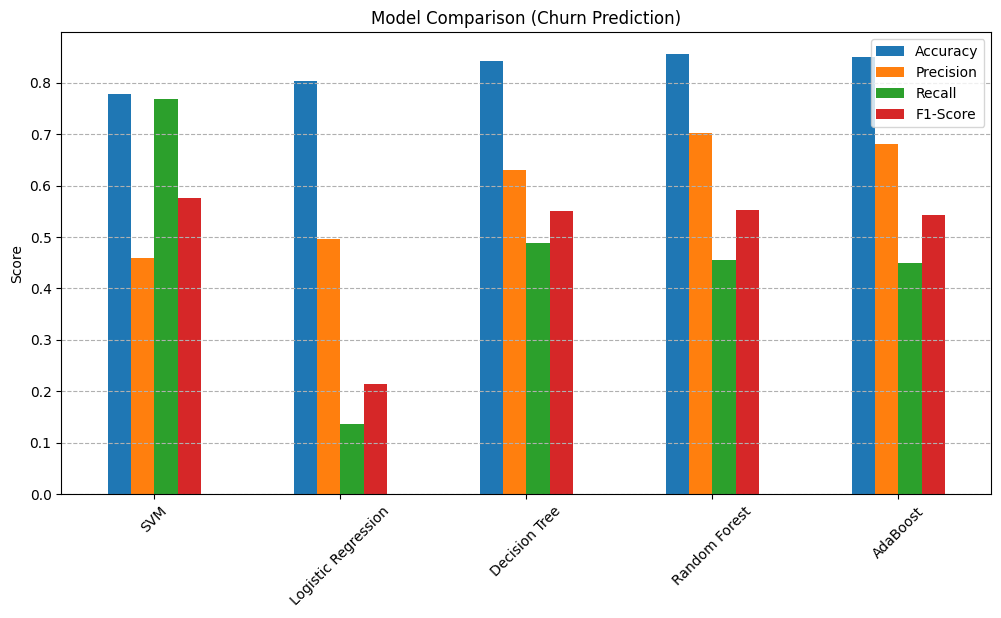

In [ ]:
import matplotlib.pyplot as plt

# Plot metrics
results_df.plot(kind='bar', figsize=(12, 6), y=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
plt.title('Model Comparison (Churn Prediction)')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.show()

saving random forest

In [ ]:
best_model_name = results_df['Accuracy'].idxmax()
best_model = models[best_model_name]

import joblib
joblib.dump(best_model, 'best_churn_model.pkl')
print(f"Best model: {best_model_name} (Accuracy: {results_df.loc[best_model_name, 'Accuracy']:.2f})")

Best model: Random Forest (Accuracy: 0.85)


In [ ]:
print("Model expects these features in order:")
print(feature_names)

Model expects these features in order:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']
